In [1]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm

In [2]:
data = pd.read_csv("../data/preprocessed/Event_traces.csv")

In [3]:
success_non_dup_data = data[data["Label"] == "Success"].drop_duplicates(subset=['Features'])
fail_non_dup_data = data[data["Label"] == "Fail"].drop_duplicates(subset=['Features'])

In [4]:
data = pd.merge(success_non_dup_data, fail_non_dup_data, how="outer").reset_index(drop=True)

In [5]:
# # Drop 30% of 'Success' rows to reduce memory consumption
# success_idx = (
#     data.loc[data["Label"] == "Success"]
#         .sample(frac=0.40, random_state=42)
#         .index
# )
# data = data.drop(success_idx).reset_index(drop=True)

In [6]:
# convert string sequence to list sequence
data["Features"] = data["Features"].map(lambda x: x[1:-1].split(","))

# can map timeinterval with the operation ran
data["TimeInterval"] = data["TimeInterval"].map(lambda x: [float(i) for i in x[1:-1].split(",")])

In [7]:
data["Features"]

0        [E5, E22, E5, E5, E26, E26, E26, E11, E9, E11,...
1        [E5, E5, E22, E5, E11, E9, E11, E9, E26, E26, ...
2        [E22, E5, E5, E5, E26, E26, E26, E11, E9, E11,...
3        [E22, E5, E5, E5, E26, E26, E9, E11, E9, E11, ...
4        [E22, E5, E5, E5, E11, E9, E11, E9, E11, E9, E...
                               ...                        
18378    [E22, E5, E5, E5, E26, E26, E26, E11, E9, E11,...
18379    [E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...
18380    [E22, E5, E5, E5, E26, E26, E26, E11, E9, E9, ...
18381    [E5, E5, E5, E22, E11, E9, E11, E9, E11, E9, E...
18382    [E22, E5, E5, E5, E26, E26, E26, E11, E9, E11,...
Name: Features, Length: 18383, dtype: object

In [8]:
# NOTE: One-Hot Encoding (Temporarily commented out to reduce memory consumption)
# Either we use one-hot encoding or text embedding to represent the log features/text

from sklearn.preprocessing import OneHotEncoder

# unique_features = data["Features"].map(lambda x: [i[1:] for i in x]).explode().unique().astype(np.int32)
# unique_features.sort()

# encoder = OneHotEncoder(sparse_output=False)
# encoded_features = encoder.fit(unique_features.reshape(-1, 1))

# data["Features_Encoded"] = data["Features"].map(lambda x: encoder.transform([[int(i[1:])] for i in x]))

In [9]:
# Text embedding using Sentence-BERT
from sentence_transformers import SentenceTransformer
template_data = pd.read_csv("../data/preprocessed/HDFS.log_templates.csv")

model_name = 'all-MiniLM-L6-v2'
model = SentenceTransformer(model_name)

embeddings = model.encode(template_data['EventTemplate'].tolist())
template_embedding_dict = {template_id: template_embedding for template_id, template_embedding in zip(template_data["EventId"].tolist(), embeddings)}
data["Features_Embedded"] = data["Features"].map(lambda x: [template_embedding_dict[i] for i in x])

/Users/alina/PycharmProjects/ml_anomaly_detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/alina/PycharmProjects/ml_anomaly_detection/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [10]:
data["Features"][0], len(data["Features"][0])

(['E5',
  'E22',
  'E5',
  'E5',
  'E26',
  'E26',
  'E26',
  'E11',
  'E9',
  'E11',
  'E9',
  'E11',
  'E9',
  'E2',
  'E3',
  'E3',
  'E4',
  'E3',
  'E4',
  'E3',
  'E3',
  'E3',
  'E4',
  'E23',
  'E23',
  'E23',
  'E21',
  'E21',
  'E21'],
 29)

In [11]:
data["Features_Embedded"][0], len(data["Features_Embedded"][0]), len(data["Features_Embedded"][0][0])

([array([-9.69047695e-02,  9.48026478e-02, -4.03593406e-02, -5.34454510e-02,
          2.99836751e-02, -1.67766791e-02,  9.62885395e-02,  2.52506863e-02,
         -8.65088310e-04, -5.21881133e-02, -2.43652388e-02, -2.18958873e-02,
         -2.99940128e-02,  6.20531337e-03,  2.94665452e-02,  3.40765230e-02,
         -2.52064355e-02,  4.57830317e-02,  2.88620722e-02, -1.12024508e-02,
         -8.57576169e-03,  7.84568340e-02, -7.27074072e-02,  1.24844974e-02,
         -5.33424057e-02,  7.95609578e-02, -3.54656093e-02, -3.67647484e-02,
          2.28036381e-02, -5.42161912e-02,  9.60010216e-02, -2.14642175e-02,
          2.79535968e-02,  4.42429818e-02,  6.99885888e-03,  5.04190139e-02,
          2.15454604e-02, -6.71684444e-02, -2.80339960e-02, -4.27213088e-02,
          2.74506807e-02,  2.09972840e-02, -4.59320880e-02, -2.68992204e-02,
         -1.21591438e-04, -2.03105132e-03, -5.11726737e-02,  5.94743863e-02,
         -2.71559786e-02, -7.65230879e-02, -3.27367745e-02,  5.17798103e-02,

In [12]:
# clean data to reduce memory usage
data = data[["Features_Embedded", "TimeInterval", "Label"]]
del model
del embeddings
del template_data

In [13]:
data["Features_Embedded"]

0        [[-0.09690477, 0.09480265, -0.04035934, -0.053...
1        [[-0.09690477, 0.09480265, -0.04035934, -0.053...
2        [[-0.06410904, 0.02497644, -0.10083461, -0.016...
3        [[-0.06410904, 0.02497644, -0.10083461, -0.016...
4        [[-0.06410904, 0.02497644, -0.10083461, -0.016...
                               ...                        
18378    [[-0.06410904, 0.02497644, -0.10083461, -0.016...
18379    [[-0.09690477, 0.09480265, -0.04035934, -0.053...
18380    [[-0.06410904, 0.02497644, -0.10083461, -0.016...
18381    [[-0.09690477, 0.09480265, -0.04035934, -0.053...
18382    [[-0.06410904, 0.02497644, -0.10083461, -0.016...
Name: Features_Embedded, Length: 18383, dtype: object

In [14]:
# Maximum length of sequence is chosen as 50 based on the distribution of sequence lengths
# Sequences beyond this length are rare and has drippled effect on buiding even sequences
# (i.e., padding/truncating) for training. Most short or medium sequences from 1 -> 40 in
# length are padded up to 200s if this maximum length is not chosen.

MAX_LEN = 50 # maximum sequence length
EMBED_DIM = 384  # for 'all-MiniLM-L6-v2'

# pad with zeros on the left to create even sequences for training
def left_pad_feature(seq, pad_len=MAX_LEN, embed_dim=EMBED_DIM):
    seq = np.stack(seq)  # shape: (L, 384)
    L = seq.shape[0]
    if L >= pad_len:
        return seq[-pad_len:]  # truncate if too long
    pad = np.zeros((pad_len - L, embed_dim), dtype=seq.dtype)
    return np.vstack([pad, seq])

In [15]:
data["Features_Embedded_Padded"] = data["Features_Embedded"].map(left_pad_feature)

In [16]:
data = data[["Features_Embedded_Padded", "TimeInterval", "Label"]]

In [17]:
data["Features_Embedded_Padded"] = data["Features_Embedded_Padded"].map(lambda x: torch.from_numpy(x))

In [18]:
data["Label"]

0        Success
1        Success
2        Success
3        Success
4        Success
          ...   
18378       Fail
18379       Fail
18380    Success
18381       Fail
18382    Success
Name: Label, Length: 18383, dtype: object

In [19]:
label_encoder = OneHotEncoder(sparse_output=False)
encoded_labels = label_encoder.fit_transform(data["Label"].values.reshape(-1, 1))

In [20]:
encoded_labels

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [1., 0.],
       [0., 1.]], shape=(18383, 2))

In [21]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [22]:
# Prepare features and labels
X = torch.stack(data["Features_Embedded_Padded"].tolist())  # shape: (N, seq_len, 384)
y = torch.from_numpy(encoded_labels)       # shape: (N, num_classes)

In [23]:
del data

In [24]:
torch.save({"X": X, "y": y}, "processed_event_and_label_tensors.pt")

In [25]:
# Train/test split (80/20)
N = len(X)
train_size = int(0.8 * N)
test_size = N - train_size
dataset = torch.utils.data.TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [26]:
# TCN Model
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, dilation=1):
        super().__init__()
        # causal padding = (k - 1) * dilation
        pad = (k - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.act = nn.ReLU()
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.conv(x)
        # crop to keep causality
        out = out[:, :, :-self.conv.padding[0]]
        res = x if self.down is None else self.down(x)
        return self.act(out + res)

class TCN(nn.Module):
    def __init__(self, in_ch, hidden=32, out_ch=1):
        super().__init__()
        self.block1 = TCNBlock(in_ch, hidden, dilation=1)
        self.block2 = TCNBlock(hidden, hidden, dilation=2)
        self.block3 = TCNBlock(hidden, hidden, dilation=4)
        self.head = nn.Conv1d(hidden, out_ch, kernel_size=1)

    def forward(self, x):
        # x input shape: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # -> (batch, features, seq)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        # (batch, out_ch, seq)
        out = self.head(x)
        # prediction at last step
        return out[:, :, -1]

In [27]:
num_classes = y.shape[1]
model = TCN(in_ch=384, hidden=32, out_ch=num_classes)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss() if num_classes > 1 else nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [28]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            targets = torch.argmax(yb, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds, pos_label=1)
    f1 = f1_score(all_targets, all_preds, pos_label=1)

    return acc, recall, f1

In [29]:
# Training loop
train_losses = []
val_accs = []
val_recalls = []
val_f1s = []

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    val_acc, val_recall, val_f1 = evaluate(model, test_loader)
    val_accs.append(val_acc)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

Epoch 1 | Train Loss: 0.3297 | Val Acc: 0.9396 | Val Recall: 0.9818 | Val F1: 0.9620
Epoch 2 | Train Loss: 0.1668 | Val Acc: 0.9497 | Val Recall: 0.9759 | Val F1: 0.9679
Epoch 3 | Train Loss: 0.1409 | Val Acc: 0.9549 | Val Recall: 0.9955 | Val F1: 0.9717
Epoch 4 | Train Loss: 0.1206 | Val Acc: 0.9619 | Val Recall: 0.9850 | Val F1: 0.9758
Epoch 5 | Train Loss: 0.1038 | Val Acc: 0.9660 | Val Recall: 0.9913 | Val F1: 0.9784
Epoch 6 | Train Loss: 0.0879 | Val Acc: 0.9753 | Val Recall: 0.9839 | Val F1: 0.9841
Epoch 7 | Train Loss: 0.0816 | Val Acc: 0.9753 | Val Recall: 0.9895 | Val F1: 0.9842
Epoch 8 | Train Loss: 0.0783 | Val Acc: 0.9744 | Val Recall: 0.9843 | Val F1: 0.9836
Epoch 9 | Train Loss: 0.0762 | Val Acc: 0.9766 | Val Recall: 0.9836 | Val F1: 0.9850
Epoch 10 | Train Loss: 0.0758 | Val Acc: 0.9763 | Val Recall: 0.9832 | Val F1: 0.9848


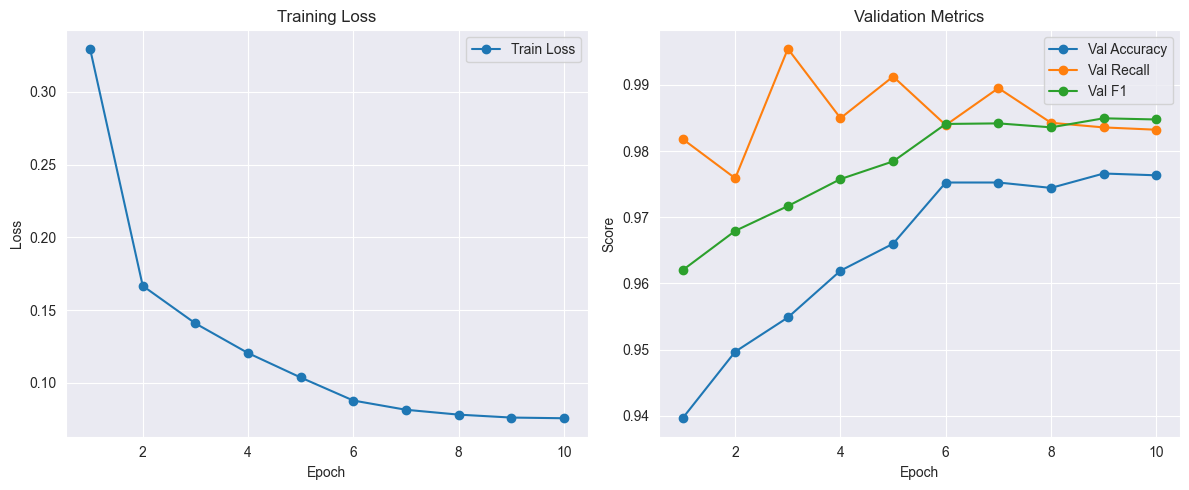

In [30]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()

# Validation metrics
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accs, label='Val Accuracy', marker='o')
plt.plot(epochs, val_recalls, label='Val Recall', marker='o')
plt.plot(epochs, val_f1s, label='Val F1', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report

all_preds = []
all_targets = []
all_scores = []
all_labels = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        scores = torch.sigmoid(logits)
        
        if num_classes > 1:
            # Multi-class/One-hot: use argmax to get class index (0, 1, etc.)
            preds = torch.argmax(logits, dim=1)
            if yb.ndim > 1:
                targets = torch.argmax(yb, dim=1)
            else:
                targets = yb
        else:
            preds = (logits.squeeze() > 0).long()
            targets = yb.squeeze().long()
            
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_scores.append(scores.cpu())
        all_labels.append(yb.cpu())

Classification Report:
              precision    recall  f1-score   support

        Fail     0.9417    0.9521    0.9469       815
     Success     0.9863    0.9832    0.9848      2862

    accuracy                         0.9763      3677
   macro avg     0.9640    0.9677    0.9658      3677
weighted avg     0.9764    0.9763    0.9764      3677



Classification Report:
              precision    recall  f1-score   support

        Fail     0.9417    0.9521    0.9469       815
     Success     0.9863    0.9832    0.9848      2862

    accuracy                         0.9763      3677
   macro avg     0.9640    0.9677    0.9658      3677
weighted avg     0.9764    0.9763    0.9764      3677



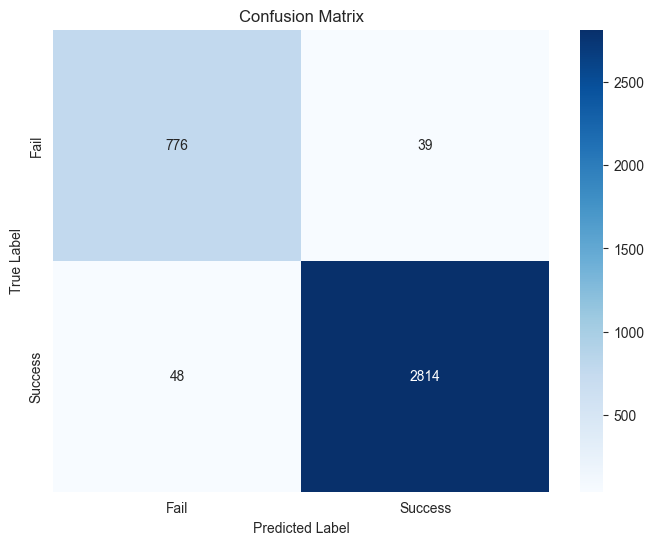

In [33]:
# Get readable class names from the label encoder
class_names = [str(c) for c in label_encoder.categories_[0]]
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# --- Visual Evaluation: Confusion Matrix ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [35]:
y_score = torch.cat(all_scores).numpy().ravel()
y_true  = torch.cat(all_labels).numpy().ravel()

pr_auc = average_precision_score(y_true, y_score)

print("PR-AUC:", pr_auc)

PR-AUC: 0.9878764506782335
